In [1]:
import geopandas as gpd
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

operation_crs = "EPSG:2056"  # Swiss coordinate system
target_crs = "EPSG:4326"  # WGS84 coordinate system

input_file_path = '../../Data/input'
output_step1_path='../../Data/output/GE/step-1'
output_step2_path='../../Data/output/GE/step-2'
output_step3_path='../../Data/output/GE/step-3'

#Read the files
index_walkability = gpd.read_parquet(f'{output_step3_path}/step3_index.parquet')
index_walkability = index_walkability.to_crs(operation_crs)

zones_girec = gpd.read_file(f'{input_file_path}/network_agreg/GEO_GIREC-SHP/GEO_GIREC.shp')
zones_girec = zones_girec.to_crs(operation_crs)

agglo_carreau = gpd.read_file(f'{input_file_path}/network_agreg/AGGLO_CARREAU_200-SHP/AGGLO_CARREAU_200.shp')
agglo_carreau = agglo_carreau.to_crs(operation_crs)

zones_communes = gpd.read_file(f'{input_file_path}/network_agreg/CAD_COMMUNE-SHP/CAD_COMMUNE.shp')
zones_communes = zones_communes.to_crs(operation_crs)

zones_communes_GE_fusionnee = gpd.read_file(f'{input_file_path}/network_agreg/CAD_COMMUNE-SHP/CAD_COMMUNES_GE_fusionnee.shp')
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.to_crs(operation_crs)


**GIREC**

In [2]:
# Spatial join
segments_girec = gpd.sjoin(index_walkability, zones_girec, how="inner", predicate="within")

# Columns to aggregate
cols = index_walkability.columns.to_list()

def weighted_mean(df, cols, weight_col):
    return (df[cols].multiply(df[weight_col], axis=0).sum() / df[weight_col].sum())

cols_to_agg = cols[3:]  # tes colonnes d'indicateurs

# Calcul pondéré
girec_stats = (
    segments_girec
        .groupby("OBJECTID")
        .apply(lambda d: weighted_mean(d, cols_to_agg, "length"))
        .reset_index()
)

# Merge back with zones_mmt polygons
zones_girec = zones_girec.merge(girec_stats, on="OBJECTID", how="left")
zones_girec

#Drop nan values 
zones_girec = zones_girec.dropna(subset=["walk_index"])

In [3]:
zones_girec.head()

,OBJECTID,NOM,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,SHAPE_LEN,...,accident,zone_apaisee,vitesse,eclairage,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité
0,31,Roulave,6620,20,00,NaN,2000020,020,1.579804e+06,7913.415859,...,0.992774,0.000000,0.706153,0.0,0.394076,0.394076,0.027279,0.592468,0.484240,0.424732
1,32,Essertines,6620,20,00,NaN,2000040,040,7.162025e+05,4123.464182,...,0.993749,0.000000,0.552689,0.0,0.394748,0.394748,0.108073,0.601578,0.386081,0.386609
2,33,La Tuilière,6620,20,00,NaN,2000010,010,1.333054e+06,6623.155220,...,0.997720,0.000000,0.658874,0.0,0.351989,0.351989,0.032470,0.535332,0.416791,0.414146
3,1,Signal,6607,7,00,NaN,0700080,080,8.244912e+05,4110.832189,...,0.994845,0.120292,0.962229,0.0,0.384106,0.384106,0.016014,0.540749,0.429020,0.519340
4,2,Veyrier - Marais,6645,48,00,NaN,4500060,060,6.213745e+05,4446.603843,...,0.974310,0.014365,0.913571,0.0,0.377852,0.377852,0.063058,0.544010,0.376466,0.475560


**Carreau 200**

In [4]:
# Spatial join: assign each segment to a carreau (grid cell)
segments_carreau = gpd.sjoin(index_walkability, agglo_carreau, how="inner", predicate="within")

# Aggregate by mean
carreau_stats = (
    segments_carreau
    .groupby("GRID_ID")
    .apply(lambda d: weighted_mean(d, cols_to_agg, "length"))
    .reset_index()
)

# Merge back to grid polygons
agglo_carreau = agglo_carreau.merge(carreau_stats, on="GRID_ID", how="left")

# Drop rows with missing values (optional)
agglo_carreau = agglo_carreau.dropna(subset=["walk_index"])

In [5]:
segments_carreau.head()

,segment_id,geometry,length,lac_cours_deau,fontaine,espaces_ouverts,rez_actif,tp,amenite,bruit,...,PARTEMP,H_P_REGG,D_POP_HA,D_EMP_HA,POP_TOT_GG,EMP_TOT_GG,POP_TOT_00,EMP_TOT_00,GEOM_AREA,GEOM_LEN
0,000000,"LINESTRING (2505952.43 1117556.984, 2505957.52...",18.612,0.0,0.0000,0.0,0.0,1.0,0.0,0.0,...,0.243655,NaN,37.25,12.00,132,54,149,48,40000.0,800.0
1,000001,"LINESTRING (2504875.759 1116854.189, 2504891.4...",17.374,0.0,0.0000,1.0,0.0,1.0,0.0,0.0,...,0.263092,NaN,147.75,52.75,576,207,591,211,40000.0,800.0
2,000002,"LINESTRING (2500026.558 1117819.303, 2500041.9...",50.000,1.0,0.0235,1.0,1.0,1.0,0.7,0.0,...,0.962452,NaN,17.00,435.75,71,1659,68,1743,40000.0,800.0
3,000003,"LINESTRING (2500045.896 1117773.339, 2500047.9...",7.199,0.0,0.0235,1.0,1.0,1.0,0.7,0.0,...,0.962452,NaN,17.00,435.75,71,1659,68,1743,40000.0,800.0
4,000004,"LINESTRING (2498574.627 1115881.29, 2498530.00...",45.125,0.0,0.0000,1.0,1.0,1.0,1.0,0.0,...,1.000000,NaN,0.00,3.00,0,0,0,12,40000.0,800.0


**[Communes](https://sitg.ge.ch/donnees/cad-commune)**

In [6]:
zones_communes.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry
0,11,Collonge-Bellerive,16,C.Be,6616,https://www.acg.ch/?q=node/158,1.069281e+07,14131.330839,"POLYGON ((2504851.598 1121190.833, 2504848.698..."
1,12,Anières,2,An,6602,https://www.acg.ch/?q=node/158,8.771935e+06,14345.239728,"POLYGON ((2507936.104 1126688.939, 2507937.789..."
2,13,Hermance,28,He,6625,https://www.acg.ch/?q=node/158,4.905640e+06,10888.811239,"POLYGON ((2507773.299 1128812.147, 2507804.379..."
3,14,Versoix,47,Vs,6644,https://www.acg.ch/?q=node/158,1.514998e+07,22048.927561,"POLYGON ((2498932.588 1130337.395, 2498892.039..."
4,1,Collex-Bossy,15,Cx,6615,https://www.acg.ch/?q=node/158,6.886683e+06,14215.534595,"POLYGON ((2498311.69 1124124.414, 2498308.252 ..."


In [7]:
# Spatial join: assign each segment to a carreau (grid cell)
segments_communes = gpd.sjoin(index_walkability, zones_communes, how="inner", predicate="within")

# Aggregate by mean
communes_stats = (
    segments_communes
    .groupby("OBJECTID")
    .apply(lambda d: weighted_mean(d, cols_to_agg, "length"))
    .reset_index()
)

# Merge back to grid polygons
zones_communes = zones_communes.merge(communes_stats, on="OBJECTID", how="left")

# Drop rows with missing values (optional)
zones_communes = zones_communes.dropna(subset=["walk_index"])

In [8]:
zones_communes.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,accident,zone_apaisee,vitesse,eclairage,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité
0,11,Collonge-Bellerive,16,C.Be,6616,https://www.acg.ch/?q=node/158,1.069281e+07,14131.330839,"POLYGON ((2504851.598 1121190.833, 2504848.698...",0.063670,...,0.875055,0.114973,0.469921,0.116845,0.372763,0.372763,0.144932,0.529975,0.351970,0.394197
1,12,Anières,2,An,6602,https://www.acg.ch/?q=node/158,8.771935e+06,14345.239728,"POLYGON ((2507936.104 1126688.939, 2507937.789...",0.110416,...,0.950854,0.145906,0.519275,0.207927,0.387800,0.387800,0.127457,0.520768,0.378646,0.455988
2,13,Hermance,28,He,6625,https://www.acg.ch/?q=node/158,4.905640e+06,10888.811239,"POLYGON ((2507773.299 1128812.147, 2507804.379...",0.376212,...,0.955586,0.130441,0.665068,0.259595,0.431822,0.431822,0.154319,0.563511,0.378519,0.502668
3,14,Versoix,47,Vs,6644,https://www.acg.ch/?q=node/158,1.514998e+07,22048.927561,"POLYGON ((2498932.588 1130337.395, 2498892.039...",0.344149,...,0.910657,0.217747,0.553963,0.060477,0.420725,0.420725,0.188388,0.547844,0.392633,0.435709
4,1,Collex-Bossy,15,Cx,6615,https://www.acg.ch/?q=node/158,6.886683e+06,14215.534595,"POLYGON ((2498311.69 1124124.414, 2498308.252 ...",0.283775,...,0.976915,0.000000,0.515080,0.016450,0.373831,0.373831,0.105882,0.551066,0.406345,0.377109


*Communes avec Genève fusionnée (1 seul polygone au lieu de 4 différents)*

In [9]:
# Spatial join: assign each segment to a carreau (grid cell)
segments_communes_GE_fusionnee = gpd.sjoin(index_walkability, zones_communes_GE_fusionnee, how="inner", predicate="within")

# Aggregate by mean
communes_GE_fusionnee_stats = (
    segments_communes_GE_fusionnee
    .groupby("OBJECTID")
    .apply(lambda d: weighted_mean(d, cols_to_agg, "length"))
    .reset_index()
)

# Merge back to grid polygons
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.merge(communes_GE_fusionnee_stats, on="OBJECTID", how="left")

# Drop rows with missing values (optional)
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.dropna(subset=["walk_index"])

In [10]:
#save the file 
zones_girec.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_girec.gpkg"), driver="GPKG")
zones_girec.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_girec.parquet')

agglo_carreau.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_carreau200.gpkg"), driver="GPKG")
agglo_carreau.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_carreau200.parquet')

zones_communes.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_communes.gpkg"), driver="GPKG")
zones_communes.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_communes.parquet')

zones_communes_GE_fusionnee.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_communes_GE_fusionnee.gpkg"), driver="GPKG")
zones_communes_GE_fusionnee.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_communes_GE_fusionnee.parquet')

**[FREQUENCE CRIMINALITE GENEVE 2024](https://statistique.ge.ch/atlas/index.php#c=indicator&view=map3)**

In [11]:
criminalite_communes = pd.read_csv(f'{input_file_path}/STAT/CRIMINALITE/CRIMINALITE_GE_2024.csv', sep=";", header=2)

criminalite_communes = criminalite_communes.rename(columns={"Loi sur les stupéfiants (LStup) : fréquence d'infractions 2024":"freq_LStup_infra","Code pénal (CP) : fréquence d'infractions 2024":"freq_CP_infra", "Loi sur les étrangers et l’intégration (LEI) : fréquence d'infractions 2024":"freq_LEI_infra"})

#convert string to float
colonnes = ['freq_LStup_infra', 'freq_CP_infra', 'freq_LEI_infra']

criminalite_communes[colonnes] = criminalite_communes[colonnes].apply(pd.to_numeric, errors='coerce')

criminalite_communes['freq_crim_mean'] = criminalite_communes[colonnes].mean(axis=1)

#print(criminalite_communes[colonnes].dtypes)

In [12]:
criminalite_communes.head()

,Code,Libellé,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean
0,6601,Aire-la-Ville,NaN,40.5,NaN,40.50
1,6602,Anières,NaN,76.2,11.1,43.65
2,6603,Avully,NaN,52.4,0.0,26.20
3,6604,Avusy,0.0,46.9,NaN,23.45
4,6605,Bardonnex,65.5,104.0,157.8,109.10


In [13]:
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.merge(
    criminalite_communes,
    left_on="NO_COM_FED",
    right_on="Code",
    how="left" 
)

In [14]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,Code,Libellé,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.208171,0.570187,0.366521,0.389493,6612,Chêne-Bougeries,3.7,73.0,5.5,27.400000
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.081631,0.597191,0.429883,0.418870,6611,Chancy,3.6,70.9,13.3,29.266667
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.097283,0.539225,0.438622,0.456206,6614,Choulex,NaN,56.9,3.2,30.050000
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.325169,0.486497,0.395950,0.424673,6613,Chêne-Bourg,3.7,105.6,14.3,41.200000
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.326031,0.476306,0.320387,0.394439,6608,Carouge (GE),3.5,93.4,7.0,34.633333


In [15]:
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.drop(columns=['Code', 'Libellé'])

In [16]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.417377,0.417377,0.208171,0.570187,0.366521,0.389493,3.7,73.0,5.5,27.400000
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.402992,0.402992,0.081631,0.597191,0.429883,0.418870,3.6,70.9,13.3,29.266667
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.398110,0.398110,0.097283,0.539225,0.438622,0.456206,NaN,56.9,3.2,30.050000
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.446061,0.446061,0.325169,0.486497,0.395950,0.424673,3.7,105.6,14.3,41.200000
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.414376,0.414376,0.326031,0.476306,0.320387,0.394439,3.5,93.4,7.0,34.633333


**[TAUX MOTORISATION CANTON GENEVE](https://statistique.ge.ch/atlas/index.php#c=indicator&view=map3)**

In [17]:
taux_motorisation_communes = pd.read_csv(f'{input_file_path}/STAT/TAUX_MOTORISATION/taux_motorisation_2024.csv', sep=";", header=2)

In [18]:
taux_motorisation_communes.head()

,Code,Libellé,Taux de motorisation 2024
0,6601,Aire-la-Ville,965
1,6602,Anières,539
2,6603,Avully,539
3,6604,Avusy,650
4,6605,Bardonnex,543


In [19]:
taux_motorisation_communes = taux_motorisation_communes.rename(columns={"Taux de motorisation 2024": "freq_voitures"})

#convert string to float
colonnes = ["freq_voitures"]

taux_motorisation_communes[colonnes] = taux_motorisation_communes[colonnes].apply(pd.to_numeric, errors='coerce')

In [20]:
taux_motorisation_communes.head()

,Code,Libellé,freq_voitures
0,6601,Aire-la-Ville,965
1,6602,Anières,539
2,6603,Avully,539
3,6604,Avusy,650
4,6605,Bardonnex,543


In [21]:
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.merge(
    taux_motorisation_communes,
    left_on="NO_COM_FED",
    right_on="Code",
    how="left" 
)

In [22]:
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.drop(columns=['Code', 'Libellé'])

In [23]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean,freq_voitures
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.417377,0.208171,0.570187,0.366521,0.389493,3.7,73.0,5.5,27.400000,428
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.402992,0.081631,0.597191,0.429883,0.418870,3.6,70.9,13.3,29.266667,513
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.398110,0.097283,0.539225,0.438622,0.456206,NaN,56.9,3.2,30.050000,593
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.446061,0.325169,0.486497,0.395950,0.424673,3.7,105.6,14.3,41.200000,383
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.414376,0.326031,0.476306,0.320387,0.394439,3.5,93.4,7.0,34.633333,423


**[CHOMAGE](https://statistique.ge.ch/atlas/index.php#c=indicator&view=map3)**

In [24]:
chomage_communes = pd.read_csv(f'{input_file_path}/STAT/CHOMAGE/chomage_2025.csv', sep=";", header=2)

In [25]:
chomage_communes.head()

,Code,Libellé,Chômeurs inscrits 2025
0,6601,Aire-la-Ville,21
1,6602,Anières,37
2,6603,Avully,31
3,6604,Avusy,23
4,6605,Bardonnex,40


In [26]:
chomage_communes = chomage_communes.rename(columns={"Chômeurs inscrits 2025": "nb_chomage"})

#convert string to float
colonnes = ["nb_chomage"]

chomage_communes[colonnes] = chomage_communes[colonnes].apply(pd.to_numeric, errors='coerce')

In [27]:
chomage_communes.head()

,Code,Libellé,nb_chomage
0,6601,Aire-la-Ville,21.0
1,6602,Anières,37.0
2,6603,Avully,31.0
3,6604,Avusy,23.0
4,6605,Bardonnex,40.0


In [28]:
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.merge(
    chomage_communes,
    left_on="NO_COM_FED",
    right_on="Code",
    how="left" 
)

In [29]:
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.drop(columns=['Code', 'Libellé'])

In [30]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean,freq_voitures,nb_chomage
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.208171,0.570187,0.366521,0.389493,3.7,73.0,5.5,27.400000,428,248.0
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.081631,0.597191,0.429883,0.418870,3.6,70.9,13.3,29.266667,513,32.0
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.097283,0.539225,0.438622,0.456206,NaN,56.9,3.2,30.050000,593,19.0
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.325169,0.486497,0.395950,0.424673,3.7,105.6,14.3,41.200000,383,215.0
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.326031,0.476306,0.320387,0.394439,3.5,93.4,7.0,34.633333,423,540.0


**EXPORT**

In [31]:
zones_communes_GE_fusionnee.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_communes_GE_fusionnee_STAT.gpkg"), driver="GPKG")
zones_communes_GE_fusionnee.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_communes_GE_fusionnee_STAT.parquet')

**CORRELATION**

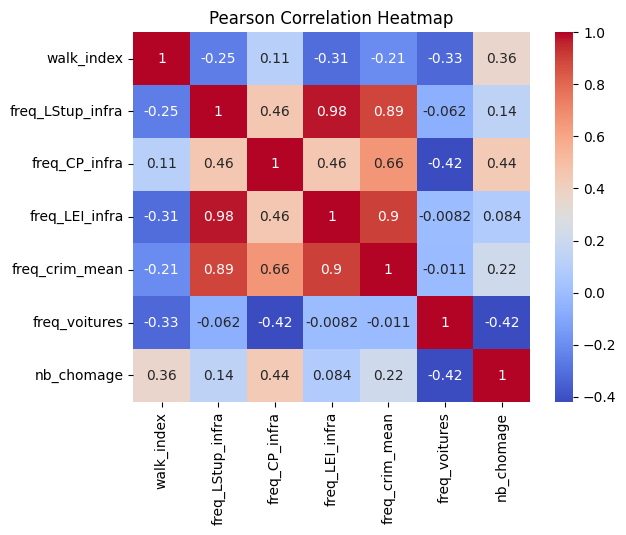

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

colonnes_corr = ['walk_index', 
                 'freq_LStup_infra', 
                 'freq_CP_infra', 
                 'freq_LEI_infra', 
                 'freq_crim_mean', 
                 'freq_voitures',
                 'nb_chomage']

zones_communes_GE_fusionnee_corr = zones_communes_GE_fusionnee[colonnes_corr].corr(method='pearson')
#print(zones_communes_corr)

sns.heatmap(zones_communes_GE_fusionnee_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()